# Examples of Matplotlib Visualization Functions

This document introduces and tests three common 2D data visualization functions in Matplotlib:
- `imshow`: Display image data
- `pcolor`: Pseudocolor plot
- `contourf`: Filled contour plot

We will demonstrate the basic usage, parameter settings, and applications in multi-subplot layouts.

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from faninsar import plots

## 1. Preparing Test Data

First, let's create different types of data for testing:

In [2]:
# Create test data

# 1. Simple 2D array
simple_data = np.random.rand(10, 10)

# 2. Grid data
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z1 = np.exp(-(X**2 + Y**2))

# 3. Data with sine waves
Z2 = np.sin(X) * np.cos(Y)

# 4. Data with noise
Z3 = Z1 + 0.1 * np.random.randn(100, 100)

print(f"simple_data shape: {simple_data.shape}")
print(f"grid data shape: {Z1.shape}")

def show_spines(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)

simple_data shape: (10, 10)
grid data shape: (100, 100)


Text(0.5, 1.0, 'basic imshow example')

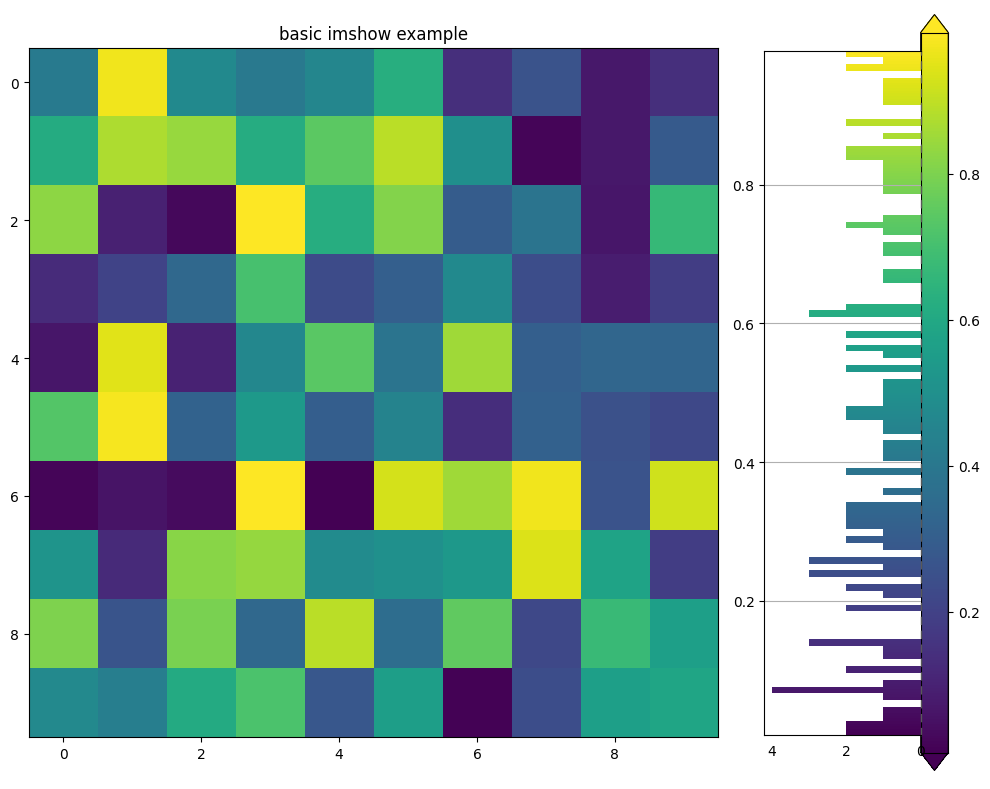

In [3]:
fig = plt.figure(figsize=(10, 8), layout="tight")
im1 = plt.imshow(simple_data)
hcb = fig.hist_colorbar(simple_data, im1, extend="both")
show_spines(hcb.ax_hist)
show_spines(hcb.ax_cbar)
hcb.ax_hist.tick_params(
        which="major",
        left=True,
        labelleft=True,
    )
hcb.ax_hist.grid()
plt.title("basic imshow example")

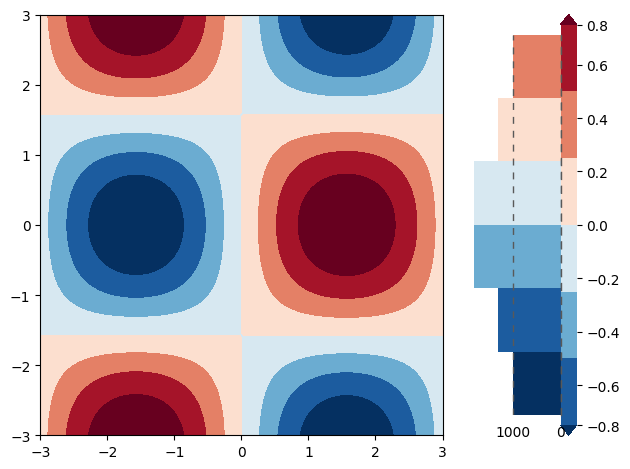

In [4]:
fig, ax = plt.subplots(
    layout="tight",
    )
diverging_data = Z2
cf2 = plt.contourf(X, Y, diverging_data, cmap="RdBu_r", extend="both")
fig.hist_colorbar(diverging_data, cf2, ax=ax, extend="both")
plt.show()

## 2. Understanding the imshow Function

The `imshow` function is used to display image data and is one of the most commonly used 2D data visualization functions.

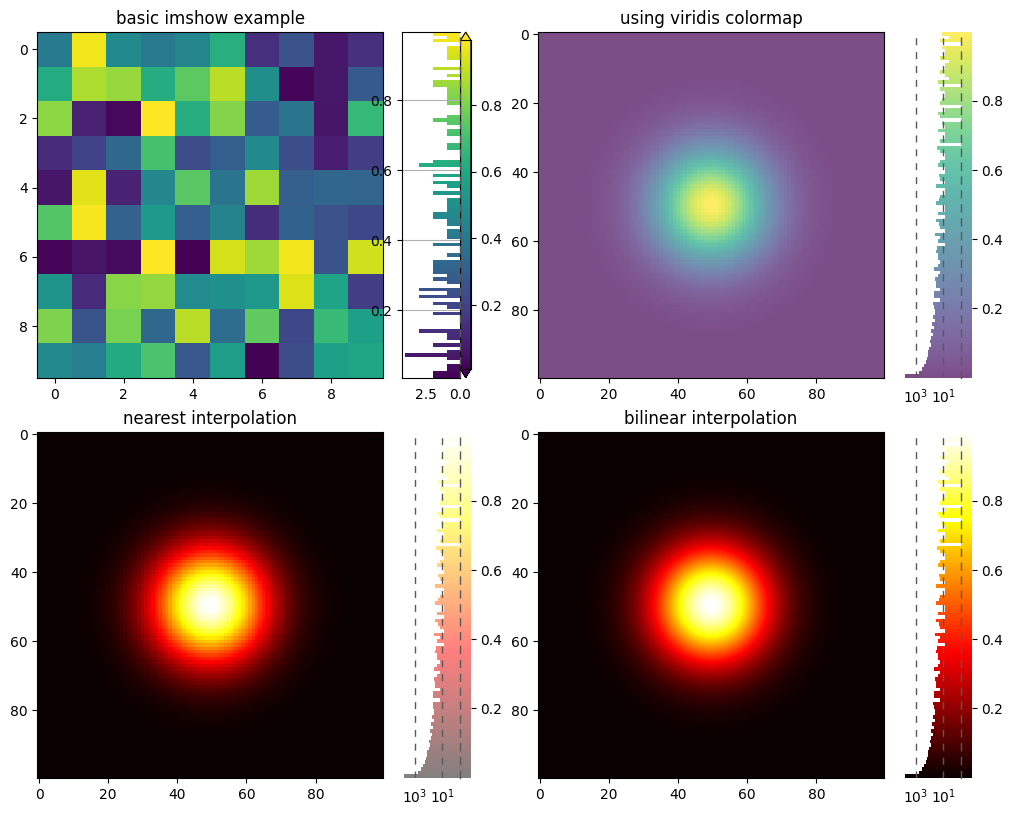

In [5]:
# 基本用法
fig = plt.figure(figsize=(10, 8), layout="constrained")

plt.subplot(221)
im1 = plt.imshow(simple_data)
hcb = fig.hist_colorbar(simple_data, im1, extend="both")
show_spines(hcb.ax_hist)
show_spines(hcb.ax_cbar)
hcb.ax_hist.tick_params(
        which="major",
        left=True,
        labelleft=True,
    )
hcb.ax_hist.grid()
plt.title("basic imshow example")

# 使用不同的颜色映射
plt.subplot(222)
im2 = plt.imshow(Z1, cmap="viridis", alpha=0.7)
fig.hist_colorbar(Z1, im2, log=True)
plt.title("using viridis colormap")

# 设置插值方法
plt.subplot(223)
im3 = plt.imshow(Z1, cmap="hot", interpolation="nearest")
fig.hist_colorbar(Z1, im3, log=True, alpha=0.5)
plt.title("nearest interpolation")

plt.subplot(224)
im4 = plt.imshow(Z1, cmap="hot", interpolation="bilinear")
fig.hist_colorbar(Z1, im4, log=True)
plt.title("bilinear interpolation")

# plt.tight_layout()
plt.show()

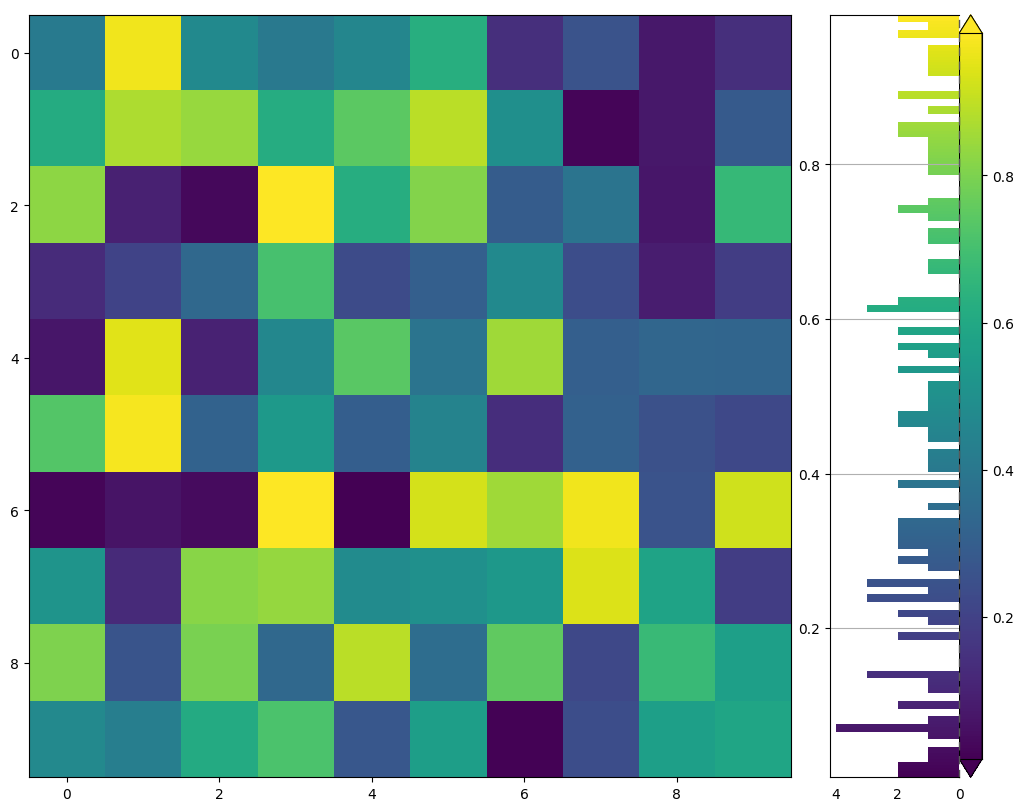

In [6]:
fig = plt.figure(figsize=(10, 8), layout="constrained")
im1 = plt.imshow(simple_data)
hcb = fig.hist_colorbar(simple_data, im1, extend="both")
show_spines(hcb.ax_hist)
show_spines(hcb.ax_cbar)
hcb.ax_hist.tick_params(
        which="major",
        left=True,
        labelleft=True,
    )
hcb.ax_hist.grid()

In [7]:
hcb.cbar._extend_patches

### Important Parameters of imshow

Let's test some important parameters of `imshow`:

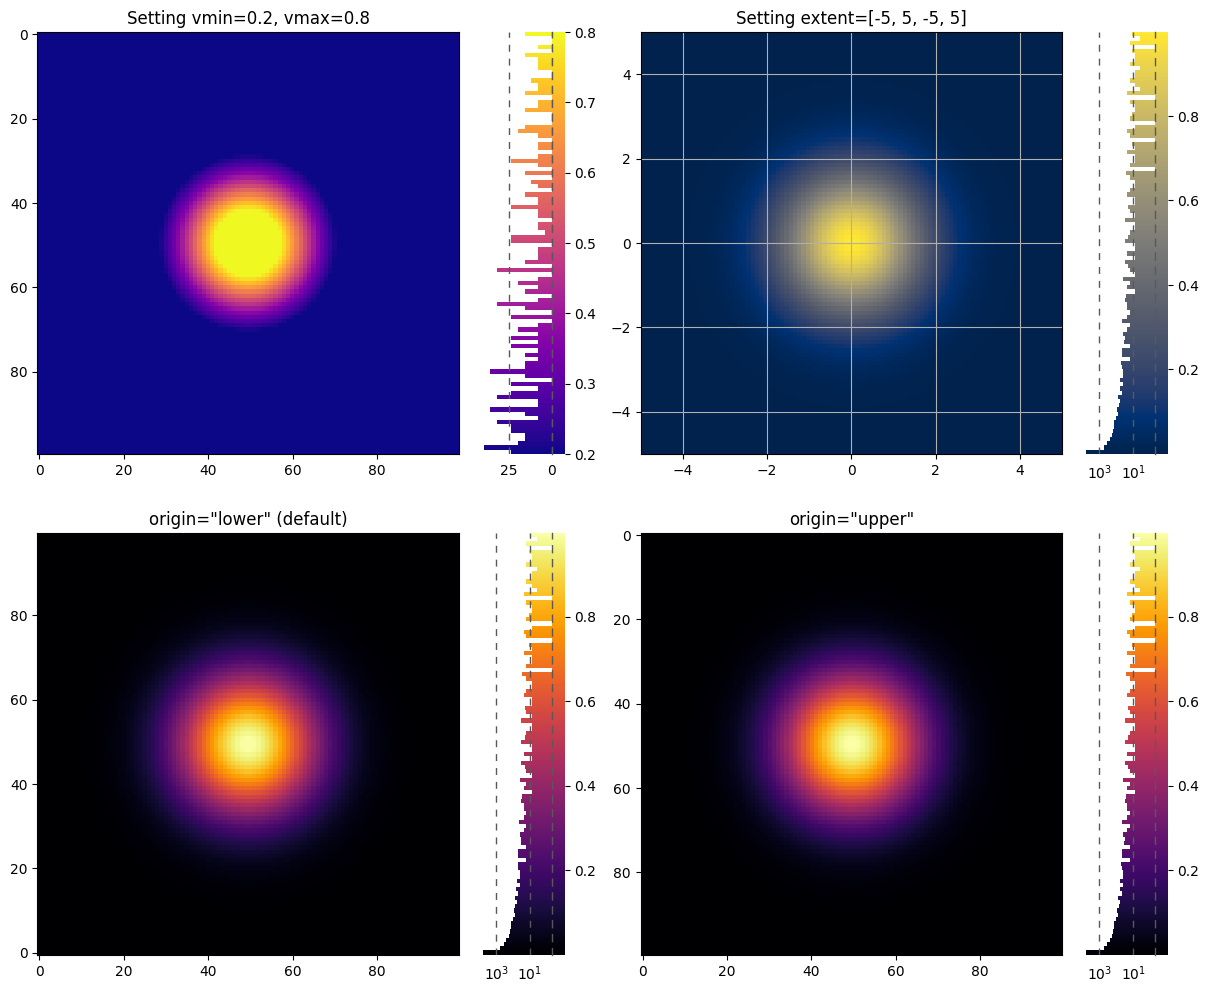

In [8]:
fig = plt.figure(figsize=(12, 10), layout="constrained")

# 1. Setting value range (vmin, vmax)
plt.subplot(221)
im1 = plt.imshow(Z1, cmap="plasma", vmin=0.2, vmax=0.8)
fig.hist_colorbar(Z1, im1)
plt.title("Setting vmin=0.2, vmax=0.8")

# 2. Setting coordinate range (extent)
plt.subplot(222)
im2 = plt.imshow(Z1, extent=[-5, 5, -5, 5], cmap="cividis")
fig.hist_colorbar(Z1, im2,log=True)
plt.title("Setting extent=[-5, 5, -5, 5]")
plt.grid(True)

# 3. Setting origin position (origin)
plt.subplot(223)
im3 = plt.imshow(Z1, origin="lower", cmap="inferno")
fig.hist_colorbar(Z1, im3, log=True)
plt.title('origin="lower" (default)')

plt.subplot(224)
im4 = plt.imshow(Z1, origin="upper", cmap="inferno")
fig.hist_colorbar(Z1, im4,log=True)
plt.title('origin="upper"')

plt.show()

### Custom Colorbar

Below we demonstrate how to customize the position and size of the colorbar:

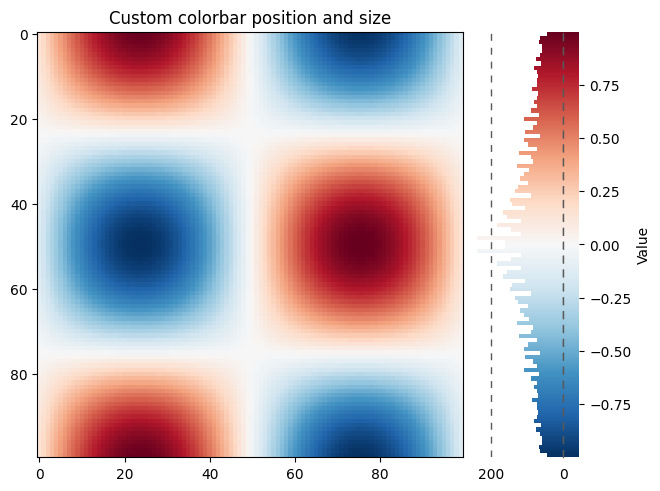

In [9]:
fig, ax = plt.subplots(layout="constrained")

# 显示图像
im = ax.imshow(Z2, cmap="RdBu_r")

# 创建一个分隔器，用于放置colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="25%", pad=0.1)

# 添加colorbar
cbar = fig.hist_colorbar(Z2, im, cax=cax)
cbar.set_cbar_label("Value")

ax.set_title("Custom colorbar position and size")
plt.show()

## 3. Understanding the pcolor Function

The `pcolor` function is used to create pseudocolor plots. Unlike `imshow`, it can directly handle non-uniform grid data.

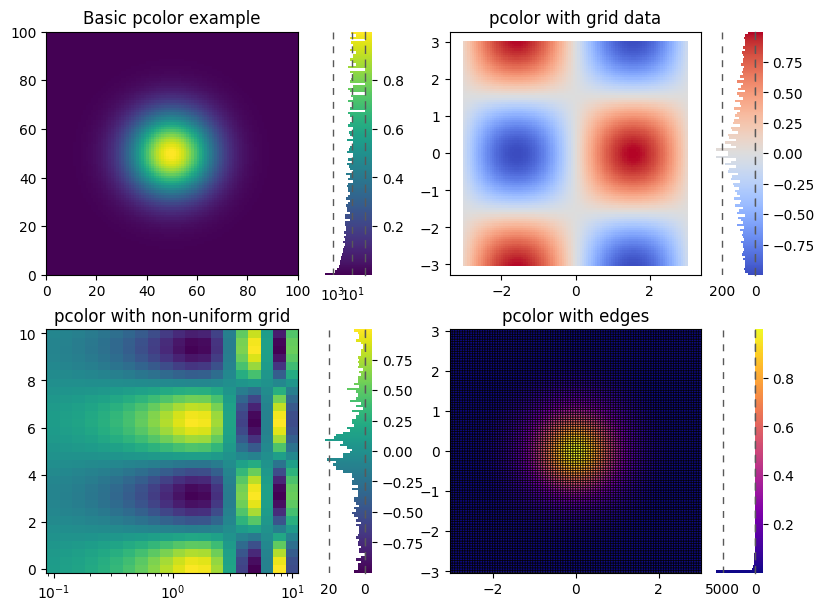

In [10]:
# Create non-uniform grid
x_non_uniform = np.logspace(-1, 1, 20)
y_non_uniform = np.linspace(0, 10, 30)
X_non, Y_non = np.meshgrid(x_non_uniform, y_non_uniform)
Z_non = np.sin(X_non) * np.cos(Y_non)

plt.figure(figsize=(8, 6),layout="constrained")

# Basic usage
plt.subplot(221)
pc1 = plt.pcolor(Z1)
fig.hist_colorbar(Z1, pc1, log=True)
plt.title("Basic pcolor example")

# Using grid data
plt.subplot(222)
pc2 = plt.pcolor(X, Y, Z2, cmap="coolwarm")
fig.hist_colorbar(Z2, pc2)
plt.title("pcolor with grid data")
plt.axis("equal")

# Using non-uniform grid
plt.subplot(223)
pc3 = plt.pcolor(X_non, Y_non, Z_non, cmap="viridis")
fig.hist_colorbar(Z_non, pc3)
plt.title("pcolor with non-uniform grid")
plt.xscale("log")  # logarithmic scale

# Setting edges
plt.subplot(224)
pc4 = plt.pcolor(X, Y, Z1, cmap="plasma", edgecolors="k", linewidths=0.5)
fig.hist_colorbar(Z1, pc4)
plt.title("pcolor with edges")

plt.show()

In [11]:
pc3.cmap.N

256

### Comparison between pcolor and pcolormesh

`pcolormesh` is an optimized version of `pcolor`, performing better with large datasets.

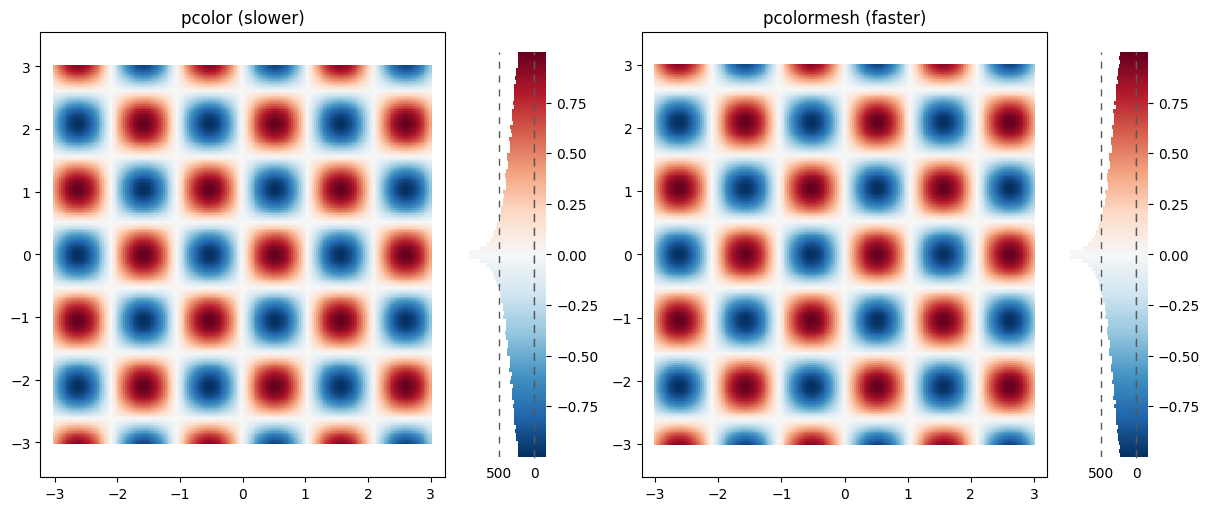

In [12]:
# Create a larger dataset
x_large = np.linspace(-3, 3, 200)
y_large = np.linspace(-3, 3, 200)
X_large, Y_large = np.meshgrid(x_large, y_large)
Z_large = np.sin(X_large * 3) * np.cos(Y_large * 3)

plt.figure(figsize=(12, 5), layout="constrained")

# pcolor
plt.subplot(121)
pc = plt.pcolor(X_large, Y_large, Z_large, cmap="RdBu_r")
fig.hist_colorbar(Z_large, pc)
plt.title("pcolor (slower)")
plt.axis("equal")

# pcolormesh
plt.subplot(122)
pcm = plt.pcolormesh(X_large, Y_large, Z_large, cmap="RdBu_r")
fig.hist_colorbar(Z_large, pcm)
plt.title("pcolormesh (faster)")
plt.axis("equal")

plt.show()

## 4. Understanding the contourf Function

The `contourf` function is used to create filled contour plots, suitable for displaying continuously varying data.

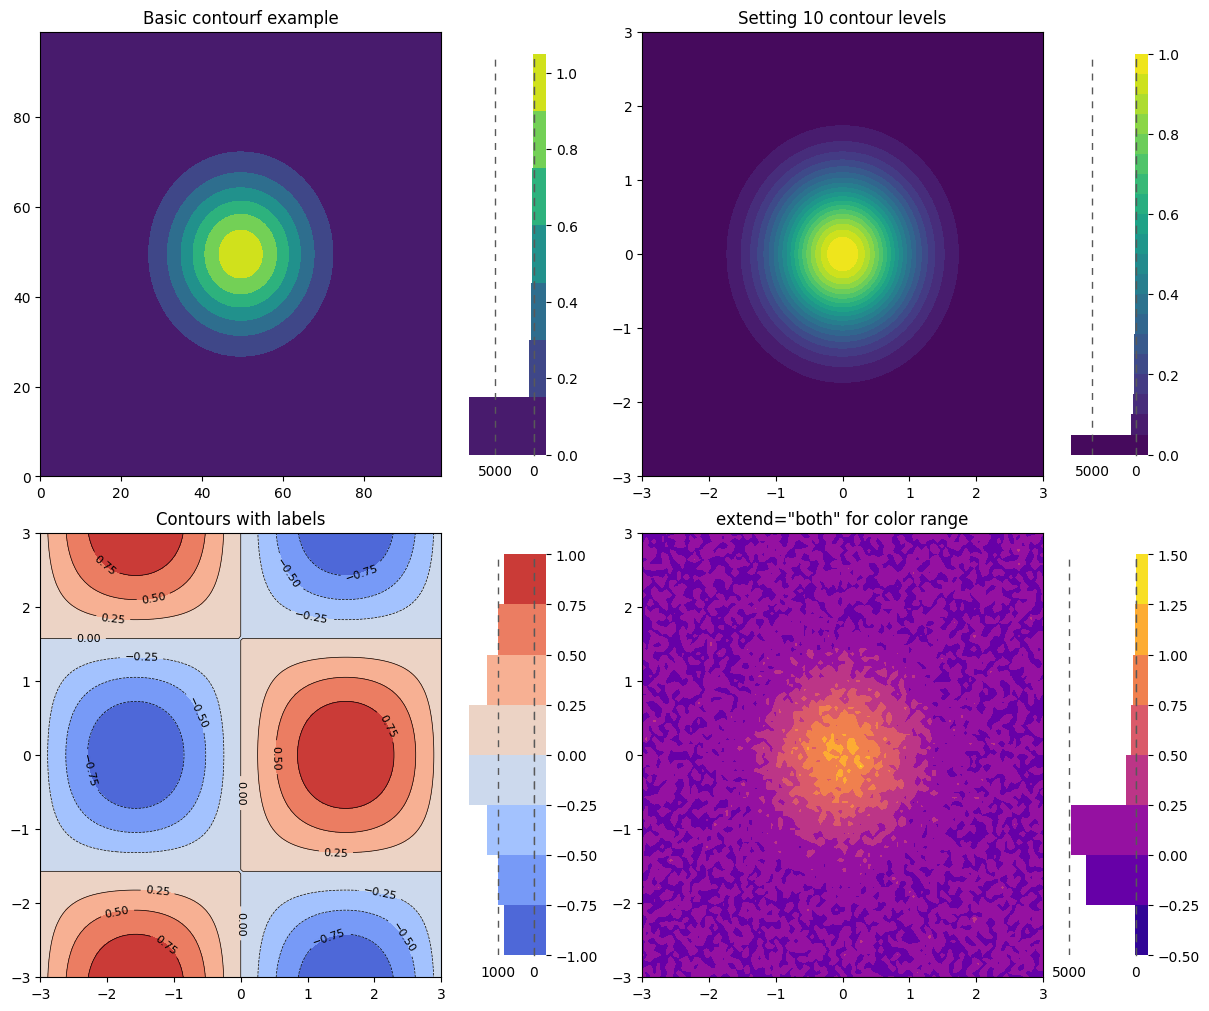

In [13]:
plt.figure(figsize=(12, 10), layout="constrained")

# Basic usage
plt.subplot(221)
cf1 = plt.contourf(Z1)
fig.hist_colorbar(Z1, cf1, extend="both")
plt.title("Basic contourf example")

# Setting contour levels
plt.subplot(222)
levels = np.linspace(0, 1, 21)
cf2 = plt.contourf(X, Y, Z1, levels=levels)
fig.hist_colorbar(Z1, cf2,extend="both")
plt.title("Setting 10 contour levels")

# Adding contour lines
plt.subplot(223)
cf3 = plt.contourf(X, Y, Z2, cmap="coolwarm")
fig.hist_colorbar(Z2, cf3, extend="both")
# Add contour lines
cs = plt.contour(X, Y, Z2, colors="k", linewidths=0.5)
plt.clabel(cs, inline=True, fontsize=8)
plt.title("Contours with labels")

# Setting fill style
plt.subplot(224)
cf4 = plt.contourf(X, Y, Z3, cmap="plasma")
fig.hist_colorbar(Z3, cf4, extend="both")
plt.title('extend="both" for color range')

plt.show()

Text(0.5, 1.0, 'extend="both" for color range')

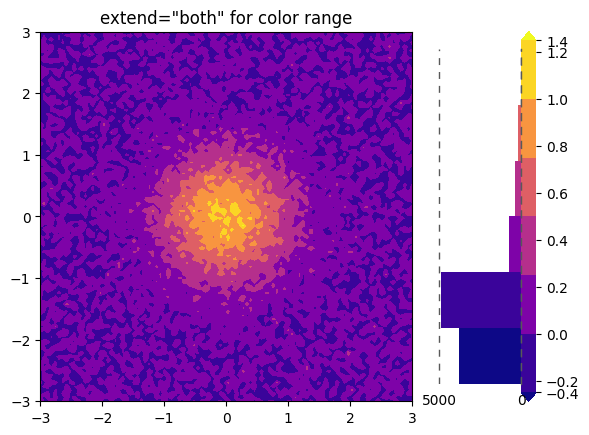

In [14]:
cf4 = plt.contourf(X, Y, Z3, cmap="plasma", extend="both")
fig.hist_colorbar(Z3, cf4, extend="both")
plt.title('extend="both" for color range')

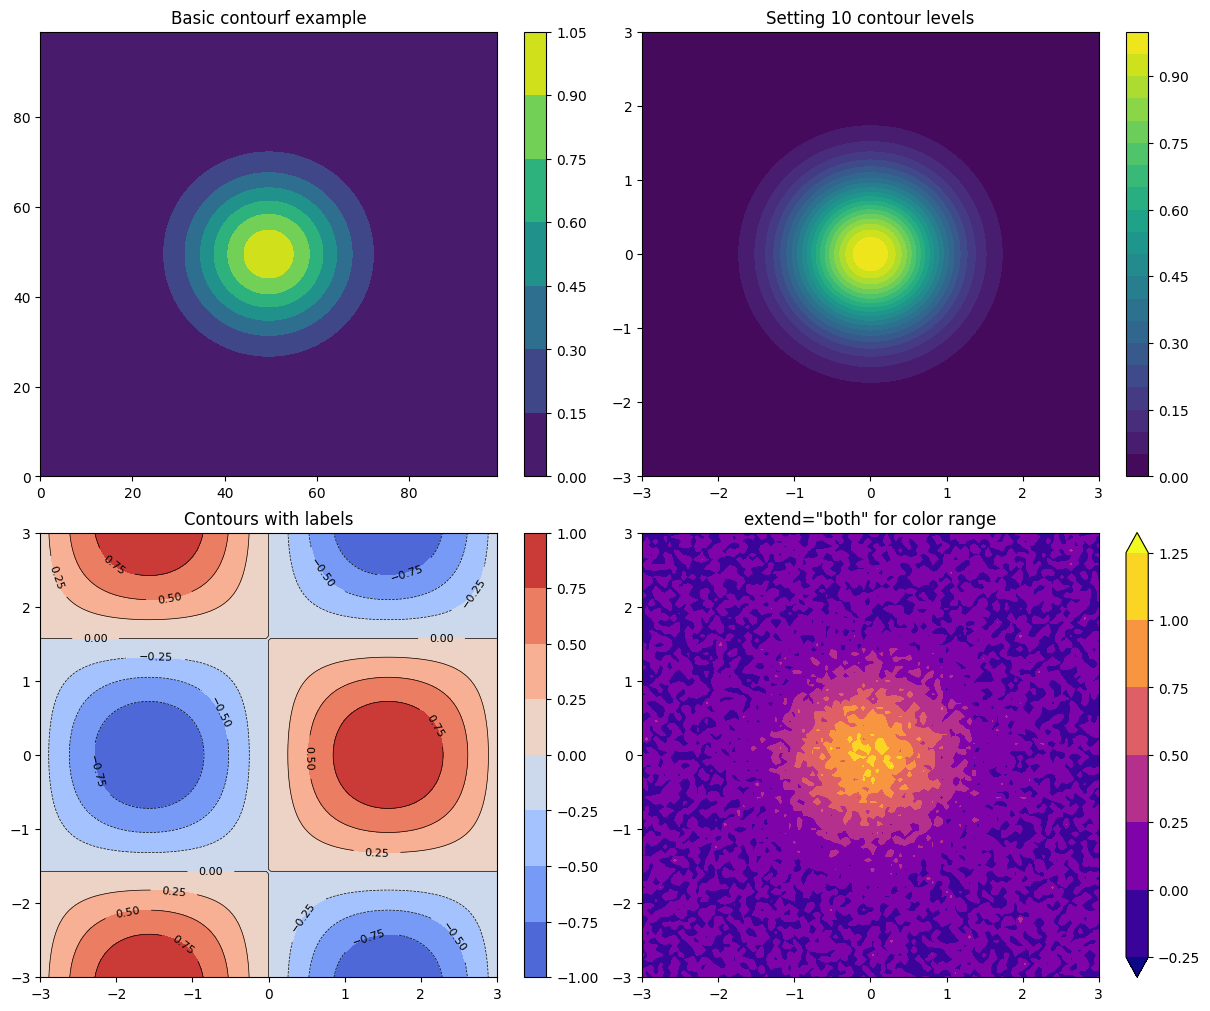

In [15]:
plt.figure(figsize=(12, 10), layout="constrained")

# Basic usage
plt.subplot(221)
cf1 = plt.contourf(Z1)
fig.colorbar(cf1, extend="both")
plt.title("Basic contourf example")

# Setting contour levels
plt.subplot(222)
levels = np.linspace(0, 1, 21)
cf2 = plt.contourf(X, Y, Z1, levels=levels)
fig.colorbar(cf2, extend="both")
plt.title("Setting 10 contour levels")

# Adding contour lines
plt.subplot(223)
cf3 = plt.contourf(X, Y, Z2, cmap="coolwarm")
fig.colorbar(cf3, extend="both")
# Add contour lines
cs = plt.contour(X, Y, Z2, colors="k", linewidths=0.5)
plt.clabel(cs, inline=True, fontsize=8)
plt.title("Contours with labels")

# Setting fill style
plt.subplot(224)
cf4 = plt.contourf(X, Y, Z3, cmap="plasma", extend="both")
fig.colorbar(cf4, extend="both")
plt.title('extend="both" for color range')

plt.show()

### Advanced Usage of contourf

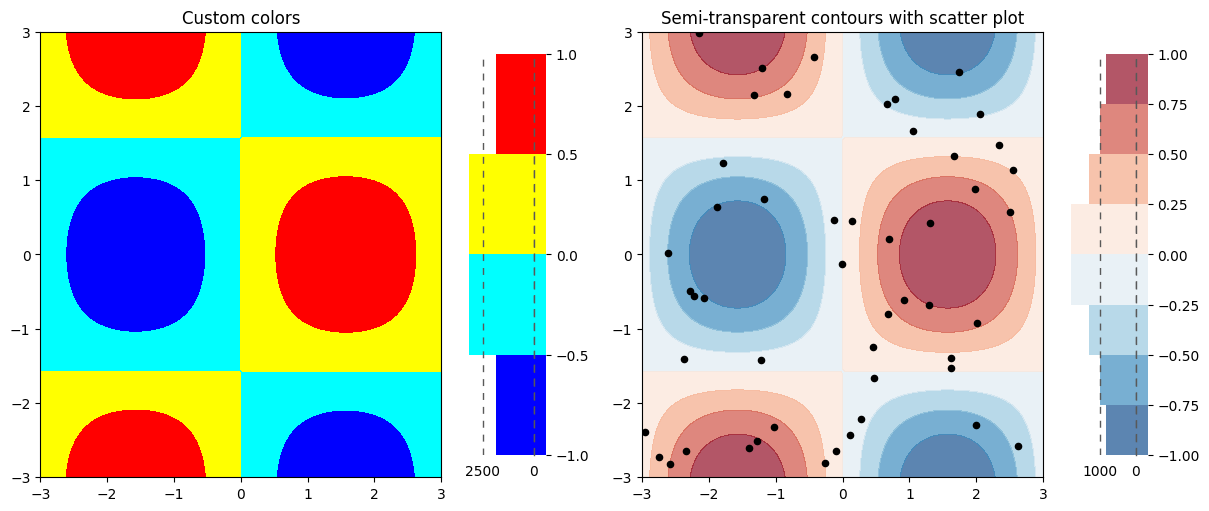

In [16]:
plt.figure(figsize=(12, 5), layout="constrained")

# Custom color mapping
plt.subplot(121)
levels = [-1, -0.5, 0, 0.5, 1]
colors = ["blue", "cyan", "yellow", "red"]
cf = plt.contourf(X, Y, Z2, levels=levels, colors=colors)
hcb = fig.hist_colorbar(Z2, cf)
hcb.set_cbar_ticks(levels)
plt.title("Custom colors")

# Setting transparency
plt.subplot(122)
cf = plt.contourf(X, Y, Z2, cmap="RdBu_r", alpha=0.7)
fig.hist_colorbar(Z2, cf)
# Add scatter plot
points_x = np.random.uniform(-3, 3, 50)
points_y = np.random.uniform(-3, 3, 50)
plt.scatter(points_x, points_y, c="k", s=20)
plt.title("Semi-transparent contours with scatter plot")

plt.show()

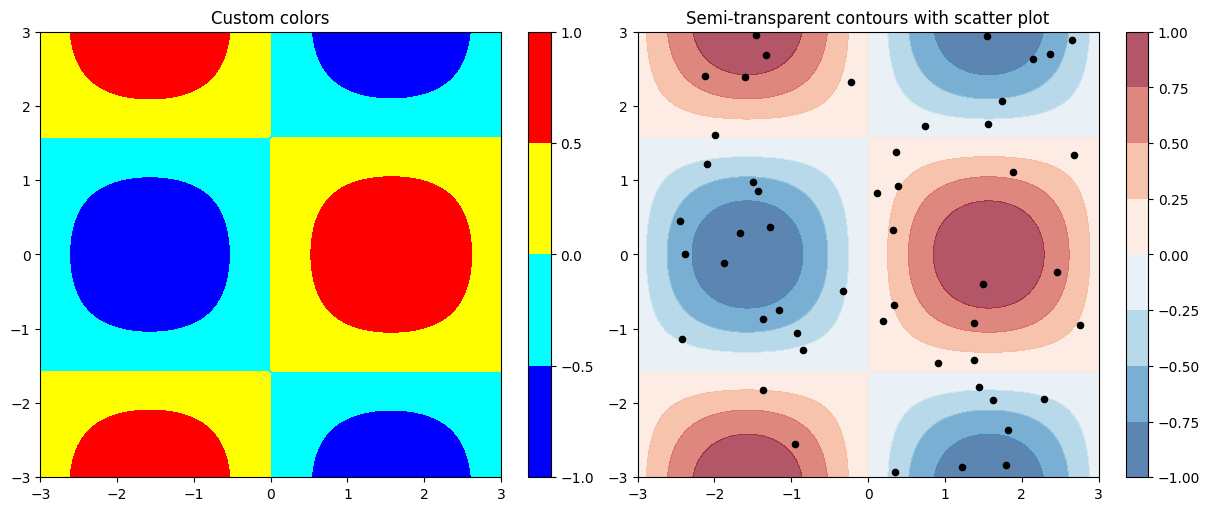

In [17]:
plt.figure(figsize=(12, 5), layout="constrained")

# Custom color mapping
plt.subplot(121)
levels = [-1, -0.5, 0, 0.5, 1]
colors = ["blue", "cyan", "yellow", "red"]
cf = plt.contourf(X, Y, Z2, levels=levels, colors=colors)
fig.colorbar(cf)
plt.title("Custom colors")

# Setting transparency
plt.subplot(122)
cf = plt.contourf(X, Y, Z2, cmap="RdBu_r", alpha=0.7)
fig.colorbar(cf)
# Add scatter plot
points_x = np.random.uniform(-3, 3, 50)
points_y = np.random.uniform(-3, 3, 50)
plt.scatter(points_x, points_y, c="k", s=20)
plt.title("Semi-transparent contours with scatter plot")

plt.show()

## 5. Comprehensive Examples with Multiple Subplots

Below, we create a comprehensive example comparing these three visualization methods in a multi-subplot layout.

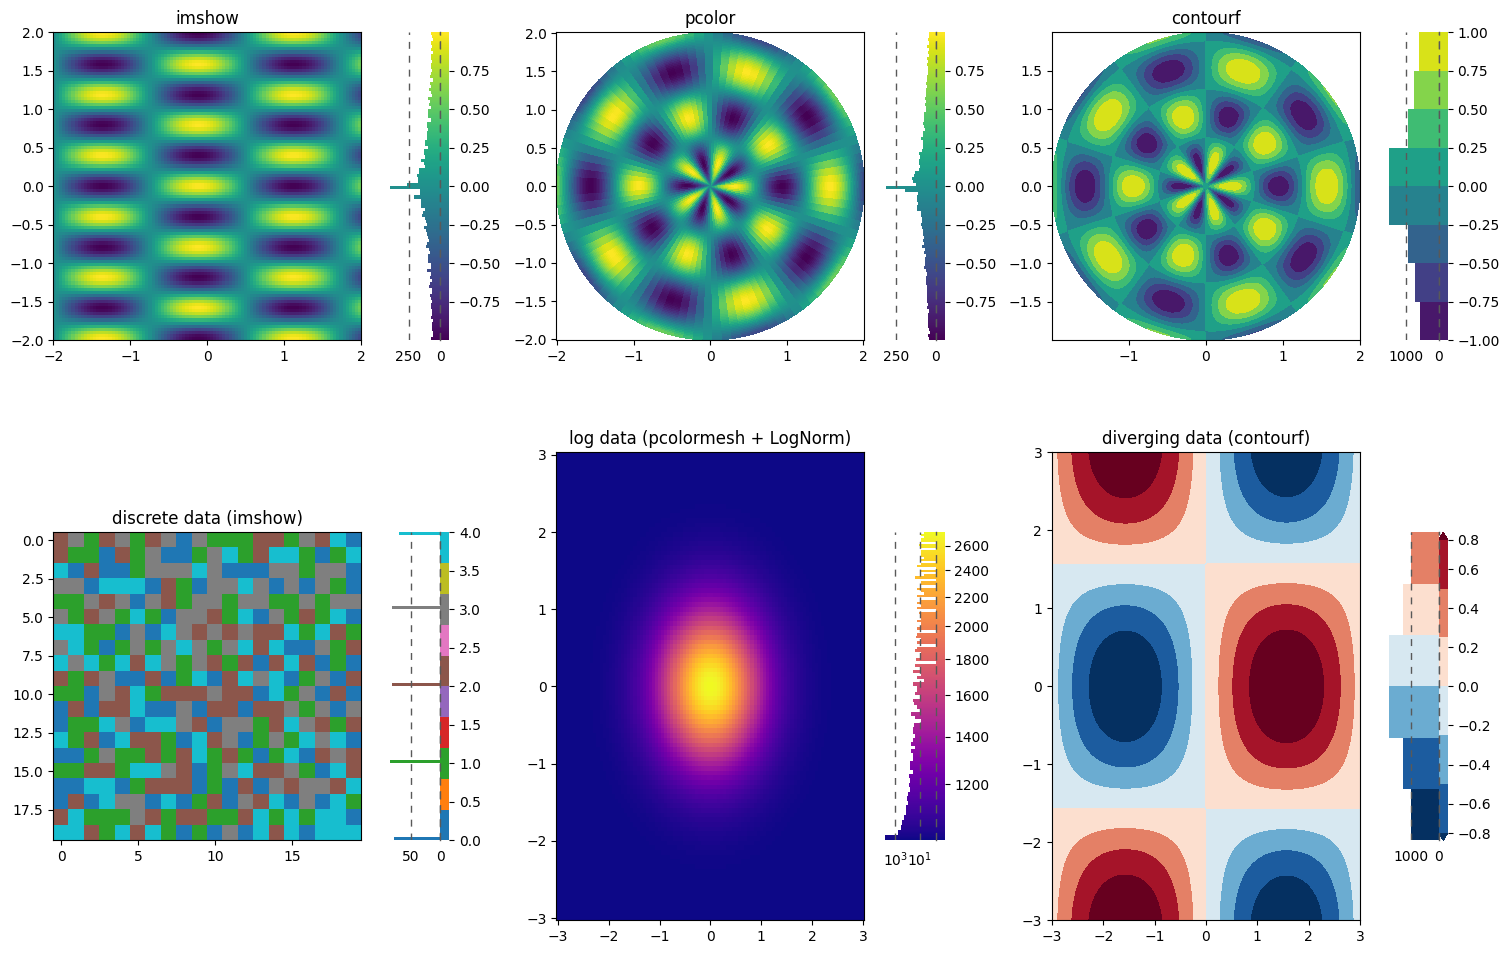

In [18]:
from faninsar import plots
import matplotlib
# 创建一个复杂的数据集
r = np.linspace(0, 2, 100)
theta = np.linspace(0, 2 * np.pi, 100)
R, Theta = np.meshgrid(r, theta)
X_polar = R * np.cos(Theta)
Y_polar = R * np.sin(Theta)
Z_polar = np.sin(5 * R) * np.cos(5 * Theta)

# 创建一个2x3的布局
fig, axes = plt.subplots(2, 3, figsize=(15, 10), layout="constrained")

# 第一行：相同数据的三种可视化方法
im = axes[0, 0].imshow(Z_polar, extent=[-2, 2, -2, 2], origin="lower", cmap="viridis")
axes[0, 0].set_title("imshow")
fig.hist_colorbar(Z_polar, im, ax=axes[0, 0])

pc = axes[0, 1].pcolor(X_polar, Y_polar, Z_polar, cmap="viridis")
axes[0, 1].set_title("pcolor")
axes[0, 1].set_aspect("equal")
fig.hist_colorbar(X_polar, pc, ax=axes[0, 1])

cf = axes[0, 2].contourf(X_polar, Y_polar, Z_polar, cmap="viridis")
axes[0, 2].set_title("contourf")
axes[0, 2].set_aspect("equal")
fig.hist_colorbar(X_polar, cf, ax=axes[0, 2])

# 第二行：不同数据类型的可视化
# 1. 离散数据
discrete_data = np.random.randint(0, 5, (20, 20))
im2 = axes[1, 0].imshow(discrete_data, cmap="tab10")
axes[1, 0].set_title("discrete data (imshow)")
fig.hist_colorbar(discrete_data, im2, ax=axes[1, 0])

# 2. 对数数据
log_data = np.exp(Z1) * 1000
pc2 = axes[1, 1].pcolormesh(
    X, Y, log_data, norm=matplotlib.colors.LogNorm(), cmap="plasma"
)
axes[1, 1].set_title("log data (pcolormesh + LogNorm)")
fig.hist_colorbar(log_data, pc2, ax=axes[1, 1], log=True)

# 3. 发散数据
diverging_data = Z2
cf2 = axes[1, 2].contourf(X, Y, diverging_data, cmap="RdBu_r", extend="both")
axes[1, 2].set_title("diverging data (contourf)")
fig.hist_colorbar(diverging_data, cf2, ax=axes[1, 2])

# plt.tight_layout()
plt.show()

## 6. Advanced Usage of Colormaps and Colorbars

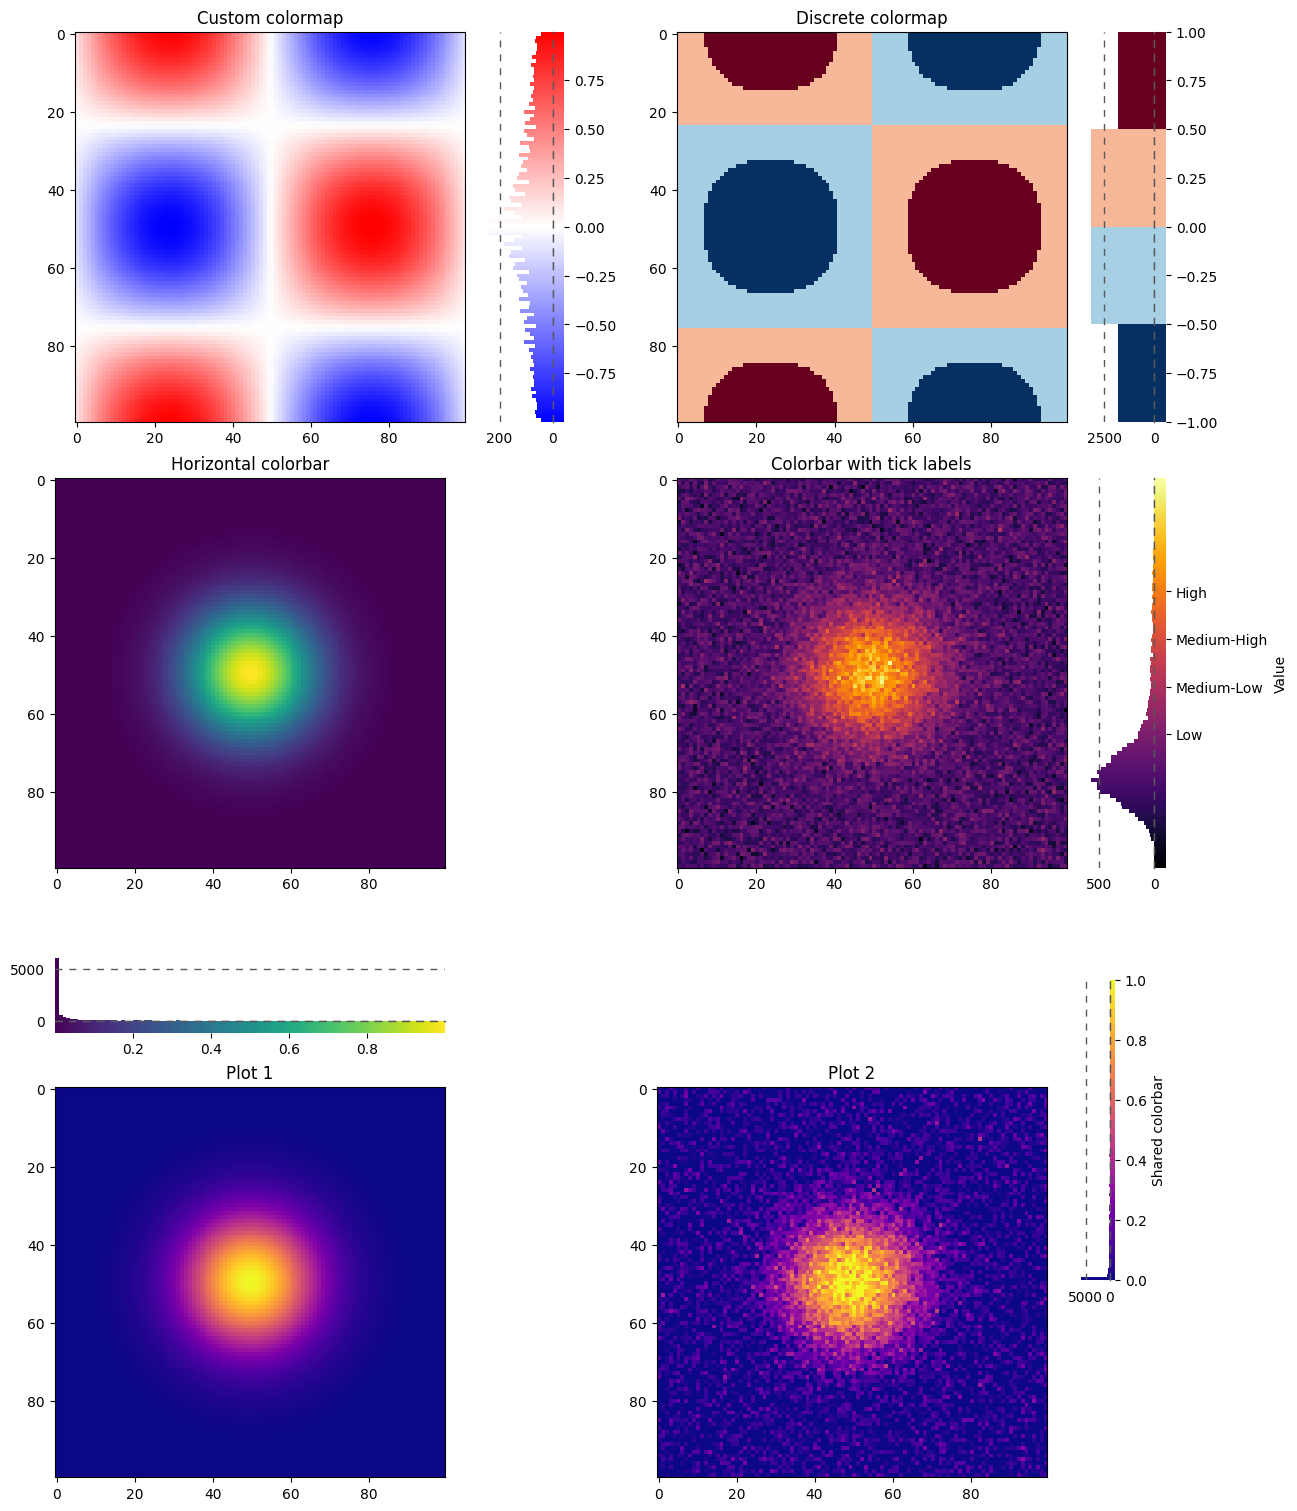

In [19]:
# Create a 3x2 layout
fig, axes = plt.subplots(3, 2, figsize=(12, 15), layout="constrained")

# 1. Custom colormap
from matplotlib.colors import LinearSegmentedColormap

colors = [(0, "blue"), (0.5, "white"), (1, "red")]
custom_cmap = LinearSegmentedColormap.from_list("custom", colors)

im1 = axes[0, 0].imshow(Z2, cmap=custom_cmap)
axes[0, 0].set_title("Custom colormap")
fig.hist_colorbar(Z2, im1, ax=axes[0, 0])

# 2. Discrete colormap
from matplotlib.colors import BoundaryNorm

levels = [-1, -0.5, 0, 0.5, 1]
norm = BoundaryNorm(levels, ncolors=256)
im2 = axes[0, 1].imshow(Z2, cmap="RdBu_r", norm=norm)
axes[0, 1].set_title("Discrete colormap")
fig.hist_colorbar(Z2, im2, ax=axes[0, 1])

# 3. Horizontal colorbar
im3 = axes[1, 0].imshow(Z1, cmap="viridis")
axes[1, 0].set_title("Horizontal colorbar")
fig.hist_colorbar(Z1, im3, ax=axes[1, 0], orientation="horizontal")

# 4. Colorbar with tick labels
im4 = axes[1, 1].imshow(Z3, cmap="inferno")
axes[1, 1].set_title("Colorbar with tick labels")
cbar = fig.hist_colorbar(Z3, im4, ax=axes[1, 1])
cbar.set_label("Value")
cbar.set_ticks([0.2, 0.4, 0.6, 0.8])
cbar.set_ticklabels(["Low", "Medium-Low", "Medium-High", "High"])

# 5. Shared colorbar
im5_1 = axes[2, 0].imshow(Z1, cmap="plasma", vmin=0, vmax=1)
axes[2, 0].set_title("Plot 1")

im5_2 = axes[2, 1].imshow(Z3, cmap="plasma", vmin=0, vmax=1)
axes[2, 1].set_title("Plot 2")

# Add shared colorbar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.2])
cbar = fig.hist_colorbar(Z1, im5_1, cax=cbar_ax)
cbar.set_label("Shared colorbar")

plt.show()

## 7. Practical Examples and Best Practices

Below are visualization examples from real-world applications.

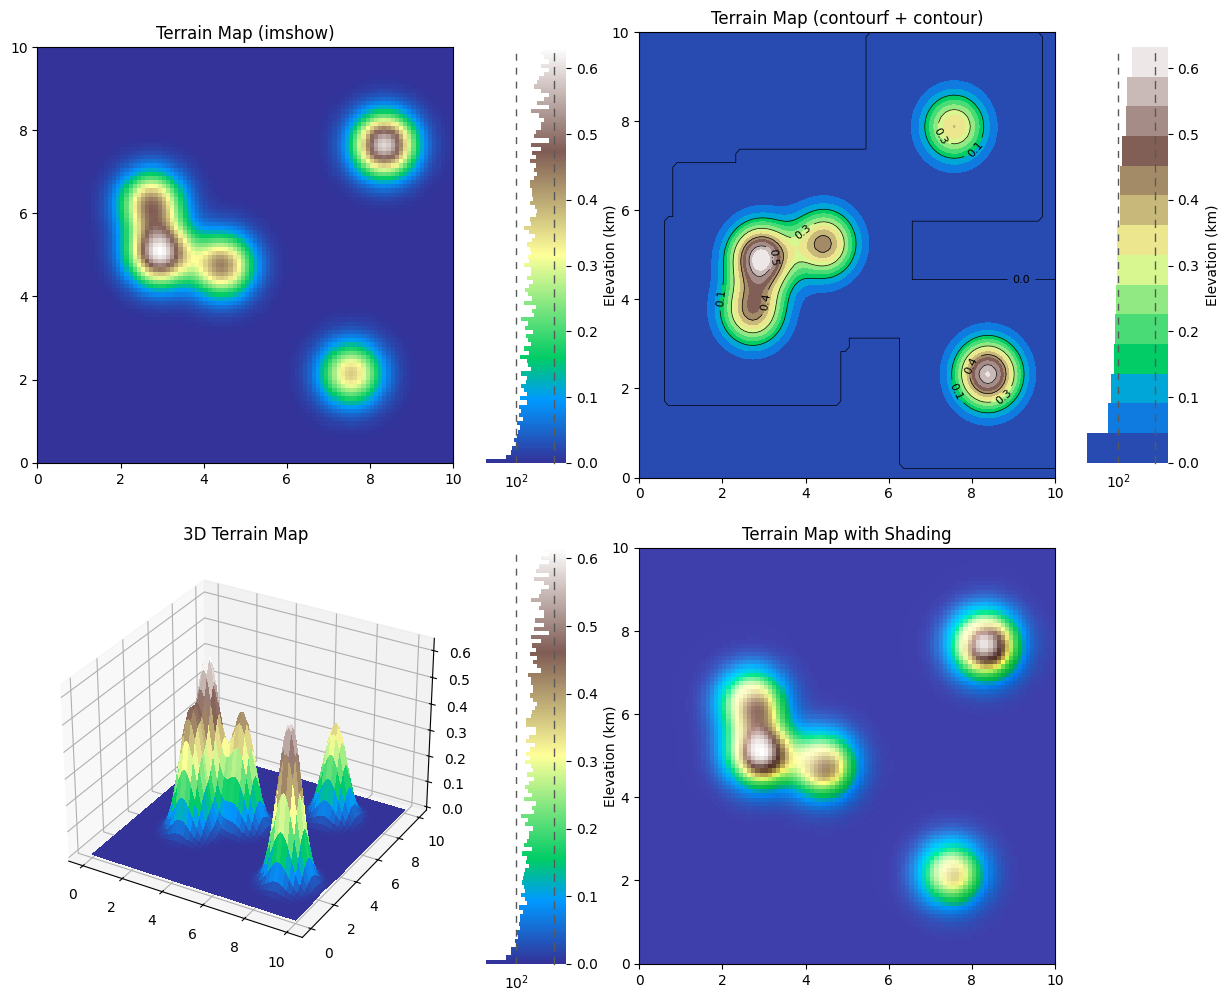

In [20]:
# Example 1: Terrain Visualization
# Create simulated terrain data
from scipy.ndimage import gaussian_filter

# Create base terrain
terrain = np.zeros((100, 100))
# Add some peaks
for _ in range(5):
    x = np.random.randint(10, 90)
    y = np.random.randint(10, 90)
    height = np.random.uniform(0.5, 1.0)
    terrain[x, y] = height

# Smooth terrain
terrain = gaussian_filter(terrain, sigma=5)*100

# Create coordinates
x_terrain = np.linspace(0, 10, 100)
y_terrain = np.linspace(0, 10, 100)
X_terrain, Y_terrain = np.meshgrid(x_terrain, y_terrain)

plt.figure(figsize=(12, 10), layout="constrained")

# 1. Display terrain using imshow
plt.subplot(221)
im = plt.imshow(terrain, cmap="terrain", extent=[0, 10, 0, 10])
fig.hist_colorbar(terrain, im, label="Elevation (km)",log=True)
plt.title("Terrain Map (imshow)")

# 2. Display terrain using contourf
plt.subplot(222)
levels = np.linspace(0, terrain.max(), 15)
cf = plt.contourf(X_terrain, Y_terrain, terrain, levels=levels, cmap="terrain")
fig.hist_colorbar(terrain, cf, label="Elevation (km)", log=True)
# Add contour lines
cs = plt.contour(
    X_terrain, Y_terrain, terrain, levels=levels[::3], colors="k", linewidths=0.5
)
plt.clabel(cs, inline=True, fontsize=8, fmt="%.1f")
plt.title("Terrain Map (contourf + contour)")

# 3. 3D surface plot
from mpl_toolkits.mplot3d import Axes3D

ax = plt.subplot(223, projection="3d")
surf = ax.plot_surface(
    X_terrain, Y_terrain, terrain, cmap="terrain", linewidth=0, antialiased=False
)
fig.hist_colorbar(terrain, surf, ax=ax, log=True, label="Elevation (km)")
ax.set_title("3D Terrain Map")

# 4. Terrain map with shading
plt.subplot(224)
# Calculate terrain gradients
dx, dy = np.gradient(terrain)
slope = np.sqrt(dx**2 + dy**2)
aspect = np.arctan2(dy, dx)

# Create shading
ls = matplotlib.colors.LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(terrain, cmap=plt.cm.terrain, vert_exag=10, blend_mode="soft")
plt.imshow(rgb, extent=[0, 10, 0, 10])
plt.title("Terrain Map with Shading")

plt.show()

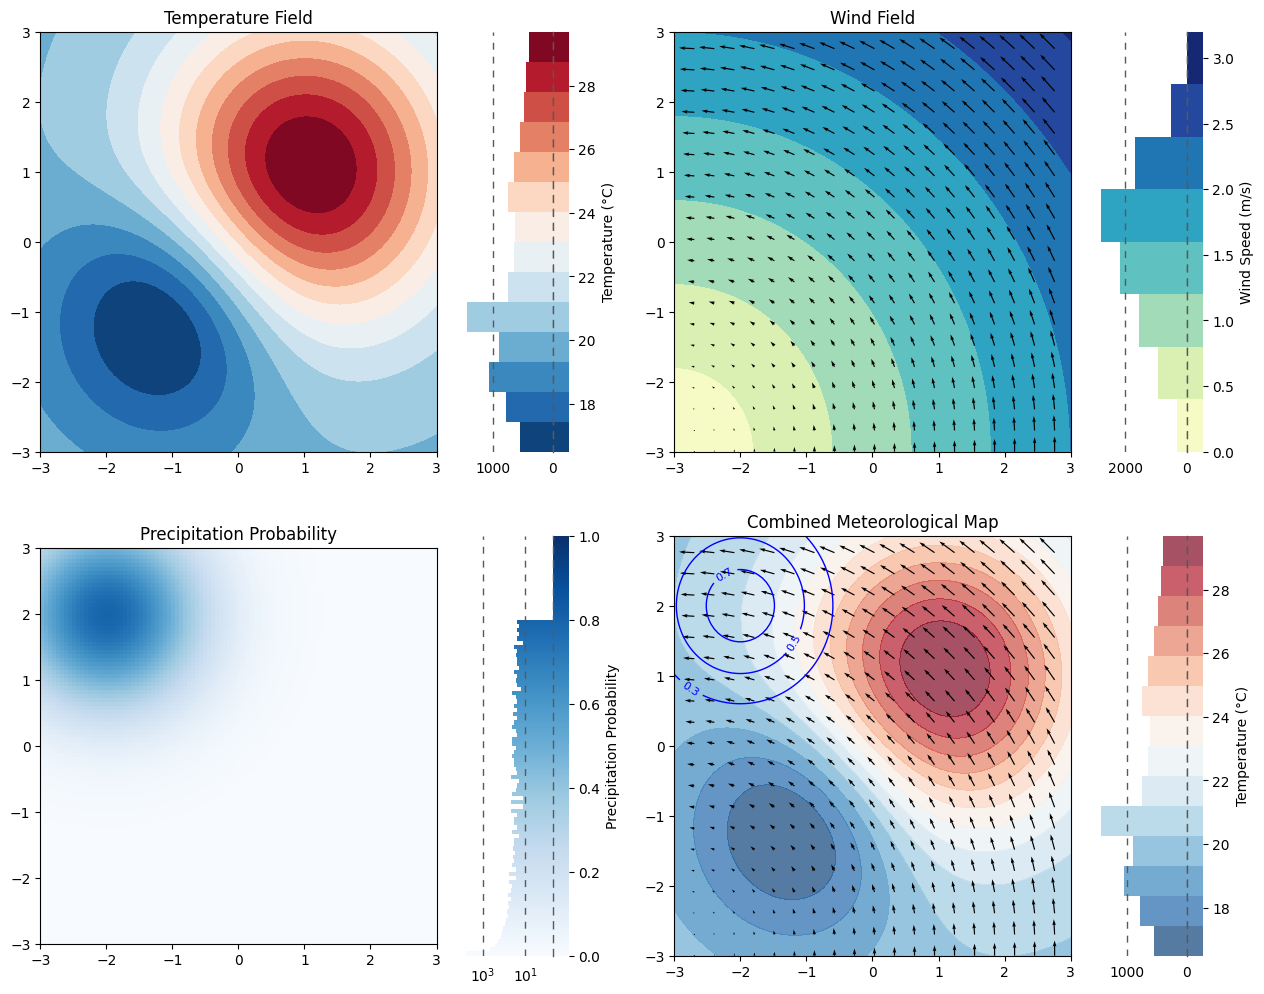

In [21]:
# Example 2: Meteorological Data Visualization

# Create simulated meteorological data
# Temperature field
temperature = (
    20
    + 10 * np.exp(-((X - 1) ** 2 + (Y - 1) ** 2) / 5)
    - 5 * np.exp(-((X + 1) ** 2 + (Y + 1) ** 2) / 3)
)

# Wind field (u, v)
u = -1 - Y / 3
v = 1 + X / 3

# Precipitation probability
precipitation = 0.8 * np.exp(-((X + 2) ** 2 + (Y - 2) ** 2) / 2)

plt.figure(figsize=(15, 12))

# 1. Temperature field
plt.subplot(221)
levels = np.linspace(temperature.min(), temperature.max(), 15)
cf = plt.contourf(X, Y, temperature, levels=levels, cmap="RdBu_r")
fig.hist_colorbar(temperature, cf, label="Temperature (°C)")
plt.title("Temperature Field")

# 2. Wind field
plt.subplot(222)
# Calculate wind speed
wind_speed = np.sqrt(u**2 + v**2)
# Plot wind speed background
cf = plt.contourf(X, Y, wind_speed, cmap="YlGnBu")
fig.hist_colorbar(wind_speed, cf, label="Wind Speed (m/s)")
# Plot wind direction arrows
# Sample grid to avoid overcrowding arrows
skip = 5
plt.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],
    u[::skip, ::skip],
    v[::skip, ::skip],
    scale=50,
    color="k",
)
plt.title("Wind Field")

# 3. Precipitation probability
plt.subplot(223)
im = plt.imshow(
    precipitation, extent=[-3, 3, -3, 3], origin="lower", cmap="Blues", vmin=0, vmax=1
)
fig.hist_colorbar(precipitation, im, label="Precipitation Probability", log=True)
plt.title("Precipitation Probability")

# 4. Combined meteorological map
plt.subplot(224)
# Temperature field as background
cf = plt.contourf(X, Y, temperature, levels=levels, cmap="RdBu_r", alpha=0.7)
fig.hist_colorbar(temperature, cf, label="Temperature (°C)")
# Precipitation contours
cs = plt.contour(
    X, Y, precipitation, levels=[0.3, 0.5, 0.7], colors="blue", linewidths=1
)
plt.clabel(cs, inline=True, fontsize=8, fmt="%.1f")
# Wind field arrows
plt.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],
    u[::skip, ::skip],
    v[::skip, ::skip],
    scale=50,
    color="k",
)
plt.title("Combined Meteorological Map")

plt.show()

## 8. Summary and Best Practices

In this document, we have covered three common 2D data visualization functions: `imshow`, `pcolor`, and `contourf`. Here are some best practices:

1. **Choosing the Right Visualization Function**:
   - `imshow`: Best for image data or regular grid data, fast rendering
   - `pcolor`/`pcolormesh`: Suitable for irregular grid data, `pcolormesh` performs better with large datasets
   - `contourf`: Ideal for contour lines and filled regions, especially for continuously varying data

2. **Colormap Selection**:
   - Continuous data: Use perceptually uniform colormaps like `viridis`, `plasma`
   - Diverging data: Use symmetric colormaps like `RdBu_r`, `coolwarm`
   - Discrete data: Use categorical colormaps like `tab10`, `Set3`

3. **Layout and Aesthetics**:
   - Use `tight_layout()` to avoid subplot overlap
   - Add titles and axis labels to each plot
   - Add appropriate labels to colorbars

4. **Performance Considerations**:
   - For large datasets, prefer `imshow` or `pcolormesh`
   - Reduce unnecessary contour levels and labels
   - Consider downsampling data for faster rendering

5. **Interactivity**:
   - Use `%matplotlib notebook` or `%matplotlib widget` for interactive plots in Jupyter
   - Consider using `mpld3` or `plotly` for enhanced interactivity

By carefully selecting visualization functions and parameters, you can effectively display the features and patterns in 2D data.